<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/CNN_Simpson_Colab_Carolina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de personajes de Los Simpson con CNN

**Objetivo:** entrenar una red neuronal convolucional simple y luego una CNN mejorada con Dropout y Data Augmentation para clasificar imágenes de personajes de Los Simpson.

Dataset: https://www.kaggle.com/datasets/alfaro96/los-simpson

## 1. Configurar Kaggle en Google Colab

Antes de ejecutar esta celda:
1. En Kaggle, ve a **Account**.
2. Crea tu API Token.
3. Descarga el archivo `kaggle.json`.
4. Súbelo en Colab cuando la celda lo solicite.

In [ ]:
# Subir kaggle.json
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

KeyboardInterrupt: 

## 2. Descargar y descomprimir el dataset

In [ ]:
!kaggle datasets download -d alfaro96/los-simpson
!unzip -q los-simpson.zip -d simpson_dataset

print("Dataset descargado correctamente")

Dataset URL: https://www.kaggle.com/datasets/alfaro96/los-simpson
License(s): MIT
100% 488M/488M [00:03<00:00, 134MB/s]

Dataset descargado correctamente


## 3. Explorar carpetas del dataset

In [ ]:
import os

for root, dirs, files in os.walk("simpson_dataset"):
    print(root, "->", len(files), "archivos")
    if len(root.split(os.sep)) > 2:
        continue

simpson_dataset -> 0 archivos
simpson_dataset/test -> 0 archivos
simpson_dataset/test/groundskeeper_willie -> 25 archivos
simpson_dataset/test/abraham_grampa_simpson -> 183 archivos
simpson_dataset/test/marge_simpson -> 259 archivos
simpson_dataset/test/chief_wiggum -> 198 archivos
simpson_dataset/test/moe_szyslak -> 291 archivos
simpson_dataset/test/lenny_leonard -> 62 archivos
simpson_dataset/test/waylon_smithers -> 37 archivos
simpson_dataset/test/comic_book_guy -> 94 archivos
simpson_dataset/test/edna_krabappel -> 92 archivos
simpson_dataset/test/krusty_the_clown -> 242 archivos
simpson_dataset/test/milhouse_van_houten -> 216 archivos
simpson_dataset/test/mayor_quimby -> 50 archivos
simpson_dataset/test/lisa_simpson -> 271 archivos
simpson_dataset/test/barney_gumble -> 22 archivos
simpson_dataset/test/maggie_simpson -> 16 archivos
simpson_dataset/test/homer_simpson -> 450 archivos
simpson_dataset/test/nelson_muntz -> 72 archivos
simpson_dataset/test/kent_brockman -> 100 archivos
si

## 4. Definir ruta de imágenes

El dataset puede venir con nombres de carpetas distintos. Esta celda busca automáticamente una carpeta que contenga subcarpetas de personajes.

In [ ]:
from pathlib import Path

base_path = Path("simpson_dataset")

candidate_dirs = []
for path in base_path.rglob("*"):
    if path.is_dir():
        subdirs = [p for p in path.iterdir() if p.is_dir()]
        image_files = list(path.rglob("*.jpg")) + list(path.rglob("*.png")) + list(path.rglob("*.jpeg"))
        if len(subdirs) >= 2 and len(image_files) > 50:
            candidate_dirs.append(path)

for i, path in enumerate(candidate_dirs):
    print(i, path)

DATA_DIR = candidate_dirs[0]
print("\nCarpeta seleccionada:", DATA_DIR)

0 simpson_dataset/test
1 simpson_dataset/train

Carpeta seleccionada: simpson_dataset/test


## 5. Crear datasets de entrenamiento y validación

Se redimensionan las imágenes a 128x128 y se separa el 20% para validación.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Cantidad de clases:", num_classes)
print("Clases:", class_names[:10])

Found 3937 files belonging to 25 classes.
Using 3150 files for training.
Found 3937 files belonging to 25 classes.
Using 787 files for validation.
Cantidad de clases: 25
Clases: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'groundskeeper_willie', 'homer_simpson']


## 6. Optimizar carga de datos

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 7. Visualizar imágenes de ejemplo

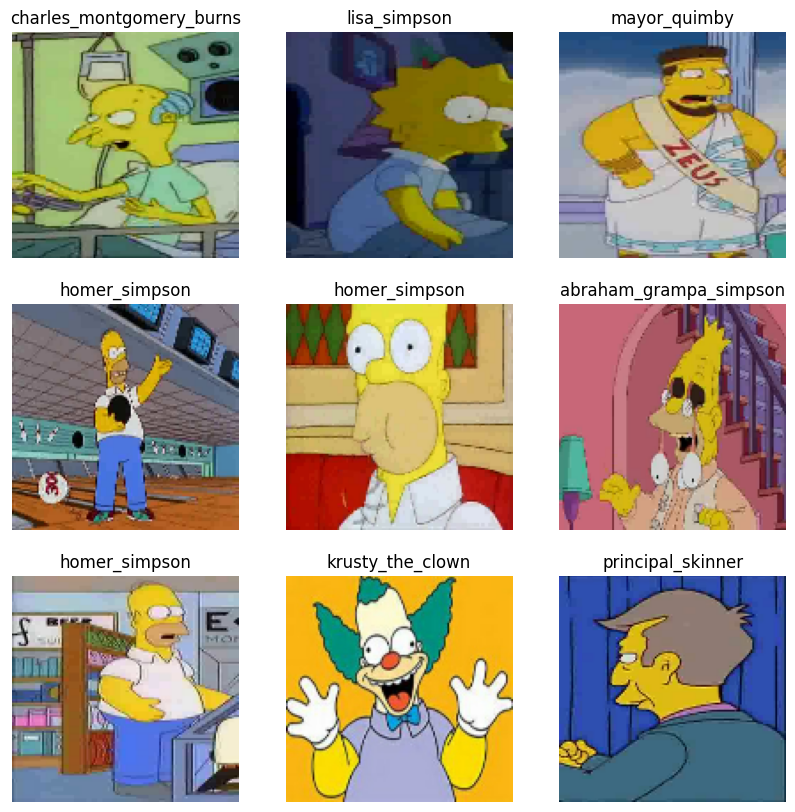

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# Modelo 1: CNN simple

Este modelo usa capas convolucionales, MaxPooling, Flatten y capas densas.

In [ ]:
model_simple = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model_simple.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_simple.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,290,905 (16.37 MB)

 Trainable params: 4,290,905 (16.37 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenar CNN simple

In [ ]:
EPOCHS = 10

history_simple = model_simple.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.1975 - loss: 2.7572 - val_accuracy: 0.3685 - val_loss: 2.3093
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.4543 - loss: 1.9884 - val_accuracy: 0.4574 - val_loss: 1.9831
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5917 - loss: 1.4174 - val_accuracy: 0.5083 - val_loss: 1.7573
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.7451 - loss: 0.8866 - val_accuracy: 0.5311 - val_loss: 1.6797
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8832 - loss: 0.3981 - val_accuracy: 0.5642 - val_loss: 1.9624
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9676 - loss: 0.1190 - val_accuracy: 0.5476 - val_loss: 2.2394
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9841 - loss: 0.0560 - val_accuracy: 0.5337 - val_loss: 2.7700
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9889 - loss: 0.0415 - val_accuracy: 0.5743 - v

## 9. Graficar resultados del modelo simple

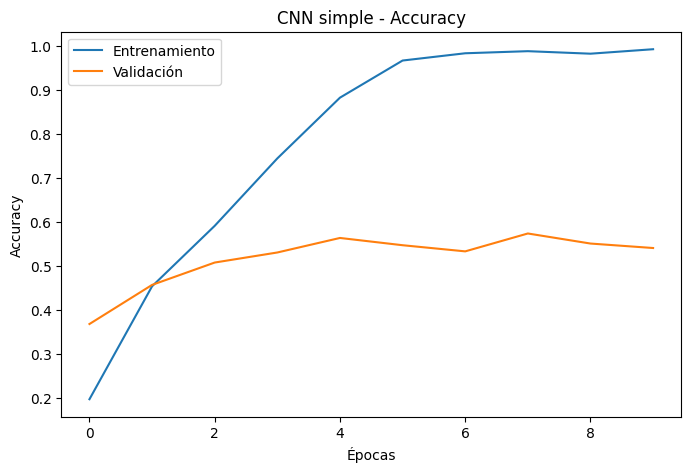

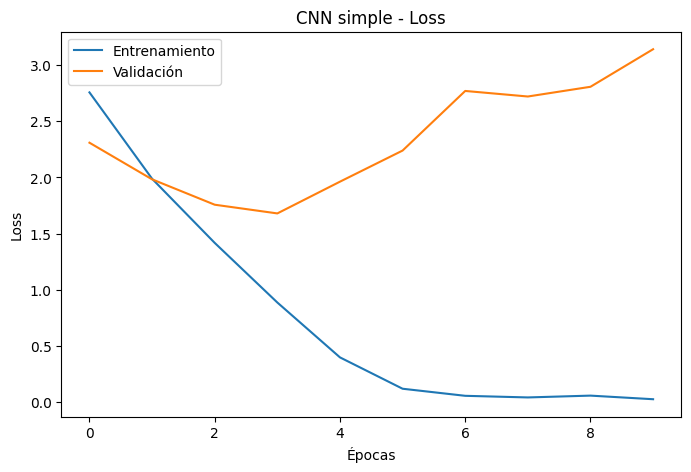

In [ ]:
def plot_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Entrenamiento")
    plt.plot(epochs_range, val_acc, label="Validación")
    plt.title(title + " - Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Entrenamiento")
    plt.plot(epochs_range, val_loss, label="Validación")
    plt.title(title + " - Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_simple, "CNN simple")

# Modelo 2: CNN mejorada

Este modelo agrega **Data Augmentation** y **Dropout** para reducir sobreajuste y mejorar la generalización.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

model_improved = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_improved.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,589,401 (17.51 MB)

 Trainable params: 4,589,401 (17.51 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Entrenar CNN mejorada

In [ ]:
EPOCHS = 15

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.1111 - loss: 3.0111 - val_accuracy: 0.1855 - val_loss: 2.7927
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.1943 - loss: 2.7277 - val_accuracy: 0.3151 - val_loss: 2.4590
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.2832 - loss: 2.4634 - val_accuracy: 0.3723 - val_loss: 2.3109
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.3692 - loss: 2.2232 - val_accuracy: 0.4867 - val_loss: 1.9371
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.4390 - loss: 2.0147 - val_accuracy: 0.5044 - val_loss: 1.7488
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.4946 - loss: 1.8001 - val_accuracy: 0.5604 - val_loss: 1.5442
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.5257 - loss: 1.6501 - val_accuracy: 0.5896 - val_loss: 1.4352
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.5578 - loss: 1.5077 - val_accuracy: 0.6252 - v

## 11. Graficar resultados del modelo mejorado

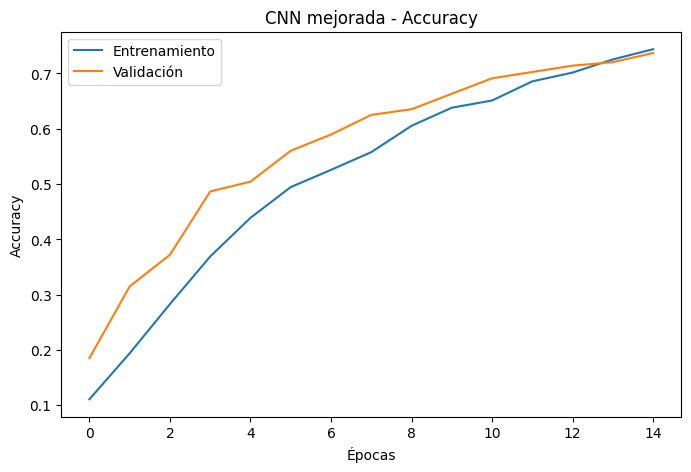

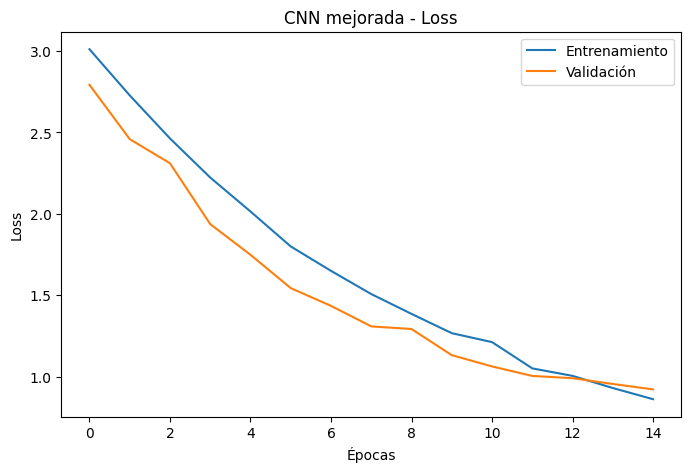

In [ ]:
plot_history(history_improved, "CNN mejorada")

## 12. Comparar modelos

In [ ]:
simple_loss, simple_acc = model_simple.evaluate(val_ds)
improved_loss, improved_acc = model_improved.evaluate(val_ds)

print("CNN simple")
print("Accuracy:", round(simple_acc, 4))
print("Loss:", round(simple_loss, 4))

print("\nCNN mejorada")
print("Accuracy:", round(improved_acc, 4))
print("Loss:", round(improved_loss, 4))

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.5413 - loss: 3.1416
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 386ms/step - accuracy: 0.7370 - loss: 0.9225
CNN simple
Accuracy: 0.5413
Loss: 3.1416

CNN mejorada
Accuracy: 0.737
Loss: 0.9225


## 13. Matriz de confusión del mejor modelo

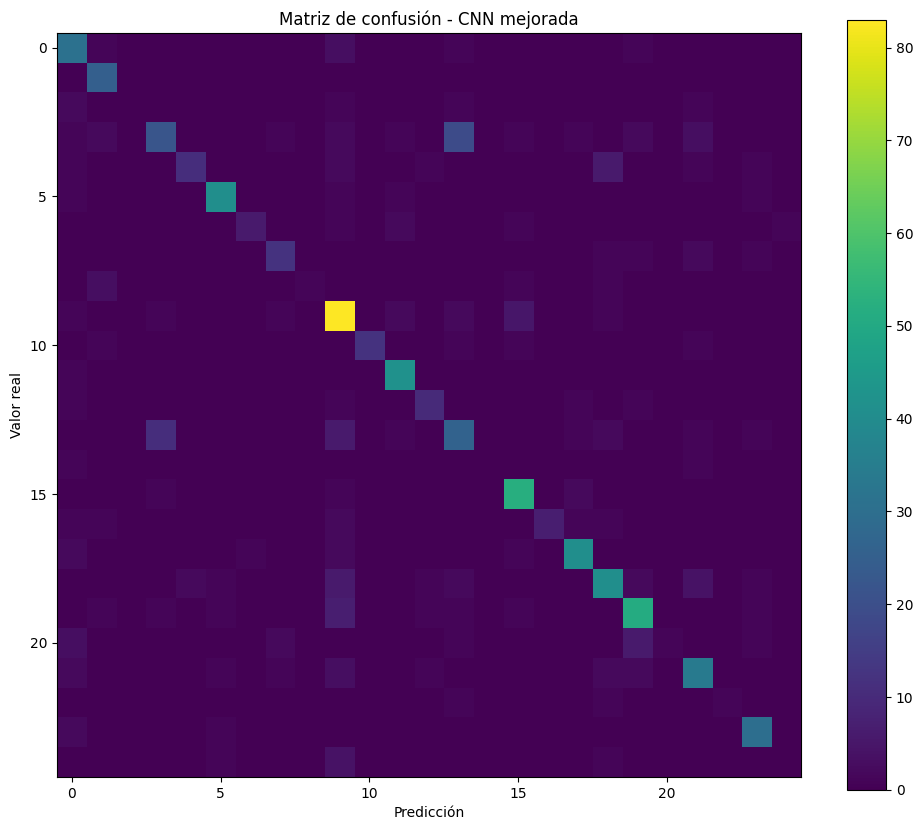

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.62      0.84      0.71        37
  apu_nahasapeemapetilon       0.74      1.00      0.85        25
           barney_gumble       0.00      0.00      0.00         5
            bart_simpson       0.61      0.40      0.48        55
charles_montgomery_burns       0.85      0.48      0.61        23
            chief_wiggum       0.89      0.91      0.90        45
          comic_book_guy       0.86      0.55      0.67        11
          edna_krabappel       0.71      0.71      0.71        17
    groundskeeper_willie       1.00      0.17      0.29         6
           homer_simpson       0.66      0.86      0.75        96
           kent_brockman       1.00      0.75      0.86        16
        krusty_the_clown       0.86      0.98      0.91        43
           lenny_leonard       0.71      0.71      0.71        14
            lisa_simpson       0.47      0.53      0.50        49
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_improved.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Matriz de confusión - CNN mejorada")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.colorbar()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## 14. Probar predicciones con imágenes de validación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step


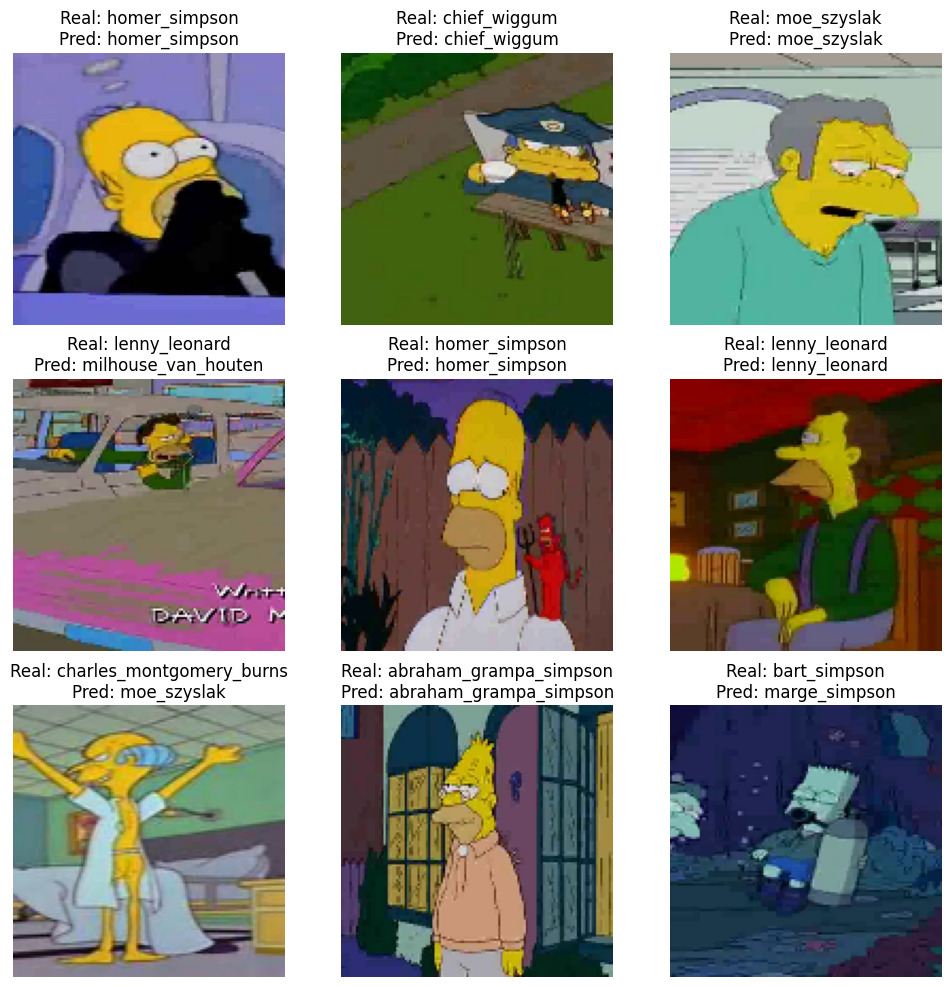

In [ ]:
plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):
    predictions = model_improved.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        real = class_names[labels[i]]
        pred = class_names[predicted_labels[i]]
        plt.title(f"Real: {real}\nPred: {pred}")
        plt.axis("off")

## 15. Conclusión sugerida

La CNN simple permitió clasificar imágenes usando capas convolucionales, pooling y capas densas. Sin embargo, el modelo mejorado incorporó Data Augmentation y Dropout, lo que ayuda a reducir el sobreajuste y a mejorar la generalización.

En un contexto de negocio, este tipo de modelo puede aplicarse en reconocimiento visual, clasificación automática de imágenes, control de calidad, análisis de productos, detección de objetos o sistemas de apoyo a la toma de decisiones basados en visión artificial.